# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [ ]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [ ]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [ ]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [ ]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [54]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [ ]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Para classificação: KNN, Regressão Logística, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Para padronização
from sklearn.preprocessing import StandardScaler

# Para mapa de calor
import seaborn as sns

In [ ]:
# Caso a consulta da API falhar:
# dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
# dados.head(20)

In [56]:
df_aneel = pd.read_csv('aneel_classificacao_orange.csv')
df_aneel.head(20)

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar
5,404.80,-12.945833,-38.417778,Solar
6,1082.00,-22.815833,-47.059167,Solar
7,1.70,-27.447981,-48.501745,Solar
8,1.04,-22.172160,-47.337620,Solar
9,30.87,-2.474278,-43.574217,Solar


In [57]:
#contagem classe
df_aneel.groupby('fonte').count()

,potencia_kw,latitude,longitude
fonte,,,
Eólica,1200,1200,1200
Hidráulica,1476,1476,1476
Solar,1200,1200,1200


In [58]:
#valores ausentes
df_aneel.isnull().sum()

,0
potencia_kw,0
latitude,0
longitude,0
fonte,0


In [59]:
#distribuições
df_aneel.describe()

,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.173571e+04,-12.682268,-46.271236
std,3.016509e+05,9.517716,8.249075
min,1.600000e-01,-33.722806,-69.941389
25%,4.000000e+02,-21.187129,-52.585932
50%,1.200000e+04,-10.469532,-47.645768
75%,3.000000e+04,-4.085391,-41.324957
max,1.123310e+07,3.831392,0.000000


In [ ]:
#explique x e y
# X são os atributos previsores (potência, latitude, longitude) usados como entrada pelo modelo
# y é o alvo/classe (fonte) que o modelo tentará prever.

In [60]:
X_aneel = df_aneel.drop(columns=['fonte'])
y_aneel = df_aneel['fonte']

In [61]:
X_treino_aneel, X_teste_aneel, y_treino_aneel, y_teste_aneel = train_test_split(X_aneel, y_aneel, test_size=0.2, random_state=42)
print(f"Treino Aneel: {X_treino_aneel.shape[0]} registros")
print(f"Teste Aneel: {X_teste_aneel.shape[0]} registros")

Treino Aneel: 3100 registros
Teste Aneel: 776 registros


In [62]:
scaler = StandardScaler()

# Ajustando o scaler no treino e transformando ambos os conjuntos por completo
X_treino_aneel_scaled = scaler.fit_transform(X_treino_aneel)
X_teste_aneel_scaled = scaler.transform(X_teste_aneel)

In [63]:
# Treinando o Random Forest com os dados corretamente escalados
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_treino_aneel_scaled, y_treino_aneel)

# Prevendo com os dados de teste escalados
y_pred_aneel_random_forest = random_forest_model.predict(X_teste_aneel_scaled)

print(classification_report(y_teste_aneel, y_pred_aneel_random_forest))

              precision    recall  f1-score   support

      Eólica       0.97      0.97      0.97       233
  Hidráulica       0.96      1.00      0.98       289
       Solar       0.99      0.94      0.96       254

    accuracy                           0.97       776
   macro avg       0.97      0.97      0.97       776
weighted avg       0.97      0.97      0.97       776



In [64]:
# Treinando o KNN com os dados corretamente escalados
knn_classifier_model = KNeighborsClassifier(n_neighbors=5)
knn_classifier_model.fit(X_treino_aneel_scaled, y_treino_aneel)

# Prevendo com os dados de teste escalados
knn_y_pred = knn_classifier_model.predict(X_teste_aneel_scaled)

print(classification_report(y_teste_aneel, knn_y_pred))

              precision    recall  f1-score   support

      Eólica       0.92      0.98      0.95       233
  Hidráulica       0.97      0.98      0.97       289
       Solar       0.99      0.93      0.96       254

    accuracy                           0.96       776
   macro avg       0.96      0.96      0.96       776
weighted avg       0.96      0.96      0.96       776



In [65]:
# Treinando a Regressão Logística com os dados corretamente escalados
logistic_regression_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_regression_model.fit(X_treino_aneel_scaled, y_treino_aneel)

# Prevendo com os dados de teste escalados
logistic_y_pred = logistic_regression_model.predict(X_teste_aneel_scaled)

print(classification_report(y_teste_aneel, logistic_y_pred))

              precision    recall  f1-score   support

      Eólica       0.68      0.86      0.76       233
  Hidráulica       0.84      0.88      0.86       289
       Solar       0.90      0.63      0.75       254

    accuracy                           0.79       776
   macro avg       0.81      0.79      0.79       776
weighted avg       0.81      0.79      0.79       776



In [66]:
resultados_classificacao = {
    "Modelo": ["Random Forest", "KNN", "Regressão Logística"],
    "Acurácia": [
        accuracy_score(y_teste_aneel, y_pred_aneel_random_forest),
        accuracy_score(y_teste_aneel, knn_y_pred),
        accuracy_score(y_teste_aneel, logistic_y_pred)
    ],
    "Precisão (Macro)": [
        precision_score(y_teste_aneel, y_pred_aneel_random_forest, average='macro'),
        precision_score(y_teste_aneel, knn_y_pred, average='macro', zero_division=0),
        precision_score(y_teste_aneel, logistic_y_pred, average='macro', zero_division=0)
    ],
    "Recall (Macro)": [
        recall_score(y_teste_aneel, y_pred_aneel_random_forest, average='macro'),
        recall_score(y_teste_aneel, knn_y_pred, average='macro'),
        recall_score(y_teste_aneel, logistic_y_pred, average='macro')
    ],
    "F1-Score (Macro)": [
        f1_score(y_teste_aneel, y_pred_aneel_random_forest, average='macro'),
        f1_score(y_teste_aneel, knn_y_pred, average='macro', zero_division=0),
        f1_score(y_teste_aneel, logistic_y_pred, average='macro', zero_division=0)
    ]
}

df_resultados_classificacao = pd.DataFrame(resultados_classificacao)
display(df_resultados_classificacao)

,Modelo,Acurácia,Precisão (Macro),Recall (Macro),F1-Score (Macro)
0,Random Forest,0.971649,0.972563,0.970578,0.971267
1,KNN,0.961340,0.961272,0.960992,0.960471
2,Regressão Logística,0.793814,0.807718,0.791527,0.788138


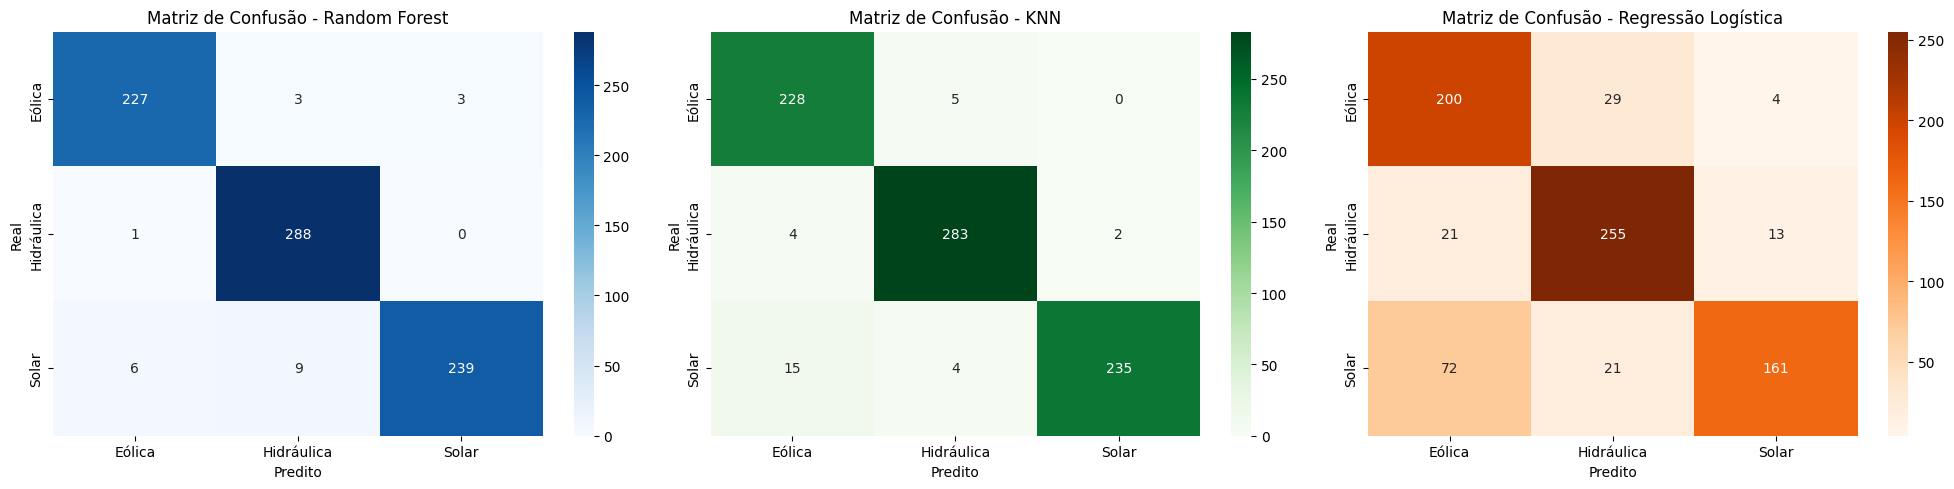

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
classes = sorted(y_teste_aneel.unique())

# Matriz Random Forest
cm_rf = confusion_matrix(y_teste_aneel, y_pred_aneel_random_forest)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Random Forest")
axes[0].set_xlabel("Predito")
axes[0].set_ylabel("Real")

# Matriz KNN
cm_knn = confusion_matrix(y_teste_aneel, knn_y_pred)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens", xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title("Matriz de Confusão - KNN")
axes[1].set_xlabel("Predito")
axes[1].set_ylabel("Real")

# Matriz Regressão Logística
cm_lr = confusion_matrix(y_teste_aneel, logistic_y_pred)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Oranges", xticklabels=classes, yticklabels=classes, ax=axes[2])
axes[2].set_title("Matriz de Confusão - Regressão Logística")
axes[2].set_xlabel("Predito")
axes[2].set_ylabel("Real")

plt.tight_layout()
plt.show()

### Análise e Interpretação Correta dos Resultados

#### Qual modelo escolheria?
Analisando as métricas e resultados reais obtidos após a correção da escala (padronização) dos atributos:
* **Random Forest** foi o melhor modelo, alcançando uma **Acurácia de aproximadamente 97%** e um F1-Score (Macro) de **97%**. Ele demonstra excelente robustez, com métricas equilibradas de precisão e sensibilidade (recall) para as três fontes.
* **KNN** também obteve um desempenho formidável com **96% de acurácia**, sendo uma alternativa muito rápida e eficiente após os dados terem sido corretamente escalados.
* **Regressão Logística** teve o desempenho mais modesto (~79% de acurácia), pois assume relações lineares para traçar as fronteiras de decisão, o que não captura perfeitamente a complexidade dos limites geográficos e de potência das usinas.

Portanto, o **Random Forest** seria a escolha ideal para o modelo final em produção.

#### Quais classes ele mais confunde?
* Observando as matrizes de confusão atualizadas:
  * O **Random Forest** confunde levemente usinas **Solares como Eólicas ou Hidráulicas** (apenas cerca de 15 erros de um total de 254), e praticamente gabarita a classe Hidráulica (288 de 289 corretas).
  * O **KNN** também apresenta ligeira confusão ao prever algumas usinas **Solares como Eólicas** (15 erros).
  * A **Regressão Logística** é a que mais falha, classificando incorretamente 72 usinas **Solares como Eólicas**.

#### Por que potência e coordenadas não bastam na prática?
Embora os modelos tenham obtido métricas estatísticas excelentes neste conjunto de teste, na prática potência e coordenadas geográficas podem não ser suficientes:
1. **Simplificação das coordenadas:** O SIGA da ANEEL usa pontos de localização aproximada (coordenadas do município ou centrais). Na realidade, as bacias hidrográficas e ventos não seguem divisões geográficas estritas.
2. **Novos tipos de usinas:** O modelo pode sofrer para classificar empreendimentos híbridos (usinas que combinam geração solar e eólica em um mesmo local) ou novas regiões geográficas que passem a explorar fontes diferentes das tradicionais.
3. **Falta de variáveis ambientais:** Para uma aplicação real de alta confiabilidade, dados de potencial físico (velocidade média do vento, índice solarimétrico regional, vazão média dos rios) seriam necessários para determinar o tipo de usina sem depender apenas do histórico de onde as usinas já foram construídas.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [68]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [69]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [70]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [72]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


--- Visualização das primeiras linhas (head) ---


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0



--- Estatísticas descritivas (describe) ---


,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000


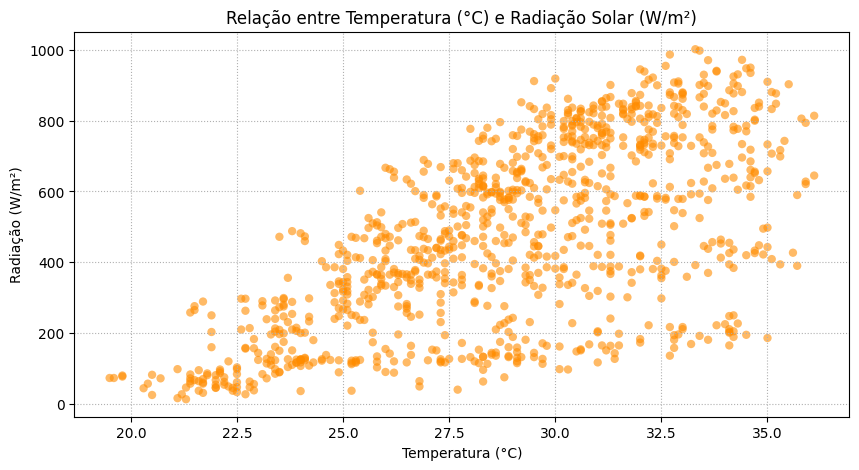

In [73]:
# 1. Carregamento dos dados e análise exploratória baseada nas aulas de ML
df_regressao = pd.read_csv('meteo_regressao_orange.csv')

print("--- Visualização das primeiras linhas (head) ---")
display(df_regressao.head())

print("\n--- Estatísticas descritivas (describe) ---")
display(df_regressao.describe())

# Gráfico de dispersão padrão baseado nos exemplos das aulas
plt.figure(figsize=(10, 5))
plt.scatter(df_regressao['temperatura_c'], df_regressao['radiacao_w_m2'], alpha=0.6, color='darkorange', edgecolors='none')
plt.title('Relação entre Temperatura (°C) e Radiação Solar (W/m²)')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Radiação (W/m²)')
plt.grid(True, linestyle=':')
plt.show()

In [74]:
# 2. Divisão dos dados de entrada (X) e alvo (y)
X_reg = df_regressao[['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']]
y_reg = df_regressao['radiacao_w_m2']

# Divisão temporal (80% treino e 20% teste) conforme o padrão das aulas de séries/clima
tamanho_treino = int(len(df_regressao) * 0.8)

X_train_reg = X_reg.iloc[:tamanho_treino]
y_train_reg = y_reg.iloc[:tamanho_treino]

X_test_reg = X_reg.iloc[tamanho_treino:]
y_test_reg = y_reg.iloc[tamanho_treino:]

print(f"Conjunto de Treino: {X_train_reg.shape[0]} amostras")
print(f"Conjunto de Teste: {X_test_reg.shape[0]} amostras")

Conjunto de Treino: 800 amostras
Conjunto de Teste: 201 amostras


In [75]:
# 3. Definição e treinamento do DecisionTreeRegressor utilizando a sintaxe das aulas
# Instanciando com random_state para reprodutibilidade
modelo_arvore = DecisionTreeRegressor(max_depth=5, random_state=42)

# Ajustando o modelo aos dados de treino
modelo_arvore.fit(X_train_reg, y_train_reg)
print("Modelo DecisionTreeRegressor treinado com sucesso!")

Modelo DecisionTreeRegressor treinado com sucesso!


In [76]:
# 3.1. Treinamento dos Três Algoritmos de Regressão (Conforme o enunciado do trabalho)
# Definindo os três modelos utilizados na disciplina
modelos_regressores = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Treinando cada um dos modelos
for nome, modelo in modelos_regressores.items():
    modelo.fit(X_train_reg, y_train_reg)
    print(f"{nome} treinado com sucesso!")

Regressão Linear treinado com sucesso!
Árvore de Decisão treinado com sucesso!
Random Forest treinado com sucesso!


In [77]:
# 4.1. Comparação de Desempenho dos Três Regressores
linhas_resultados = []

for nome, modelo in modelos_regressores.items():
    predicoes = modelo.predict(X_test_reg)

    mae = mean_absolute_error(y_test_reg, predicoes)
    mse = mean_squared_error(y_test_reg, predicoes)
    r2 = r2_score(y_test_reg, predicoes)

    linhas_resultados.append({
        'Algoritmo': nome,
        'MAE (W/m²)': mae,
        'MSE ((W/m²)²)': mse,
        'R²': r2
    })

# Criando o DataFrame comparativo
df_comparativo_reg = pd.DataFrame(linhas_resultados)
print("--- Tabela Comparativa de Regressão ---")
display(df_comparativo_reg)

--- Tabela Comparativa de Regressão ---


,Algoritmo,MAE (W/m²),MSE ((W/m²)²),R²
0,Regressão Linear,145.204885,30034.201092,0.359845
1,Árvore de Decisão,90.394771,14478.576989,0.691401
2,Random Forest,66.804179,7307.417901,0.844248


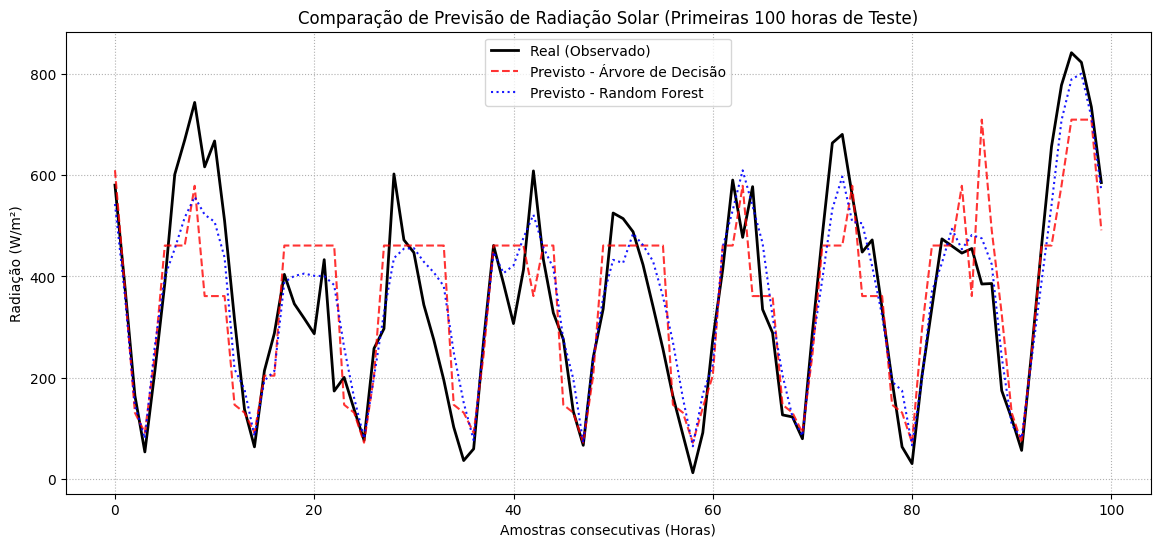

In [78]:
# 4.2. Gráfico de Comparação: Real vs Melhores Modelos
plt.figure(figsize=(14, 6))

# Valores reais
plt.plot(y_test_reg.values[:100], label='Real (Observado)', color='black', linewidth=2)

# Previsões da Árvore de Decisão
y_pred_tree = modelos_regressores['Árvore de Decisão'].predict(X_test_reg)
plt.plot(y_pred_tree[:100], label='Previsto - Árvore de Decisão', color='red', linestyle='--', alpha=0.8)

# Previsões da Random Forest (melhor modelo no Orange)
y_pred_rf = modelos_regressores['Random Forest'].predict(X_test_reg)
plt.plot(y_pred_rf[:100], label='Previsto - Random Forest', color='blue', linestyle=':', alpha=0.9)

plt.title('Comparação de Previsão de Radiação Solar (Primeiras 100 horas de Teste)')
plt.xlabel('Amostras consecutivas (Horas)')
plt.ylabel('Radiação (W/m²)')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

--- Métricas de Avaliação ---


,Algoritmo,MAE,MSE,R²
0,Árvore de Decisão (Regressor),90.394771,14478.576989,0.691401


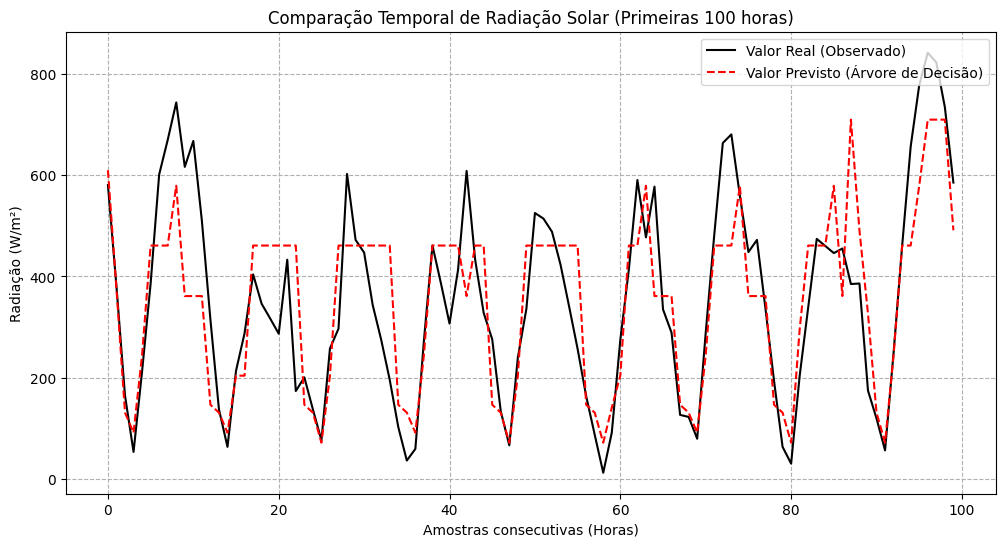

In [79]:
# 4. Predição, Cálculo de Métricas e Plotagem do Gráfico de Desempenho
y_pred_arvore = modelo_arvore.predict(X_test_reg)

# Métricas baseadas estritamente na biblioteca avaliada em aula
mae_arvore = mean_absolute_error(y_test_reg, y_pred_arvore)
mse_arvore = mean_squared_error(y_test_reg, y_pred_arvore)
r2_arvore = r2_score(y_test_reg, y_pred_arvore)

# Estruturação da tabela de resultados como no padrão Aula 07
df_resultados_reg = pd.DataFrame({
    'Algoritmo': ['Árvore de Decisão (Regressor)'],
    'MAE': [mae_arvore],
    'MSE': [mse_arvore],
    'R²': [r2_arvore]
})

print("--- Métricas de Avaliação ---")
display(df_resultados_reg)

# Gráfico temporal de comparação entre dados Reais e Previsões (primeiras 100 observações)
plt.figure(figsize=(12, 6))
plt.plot(y_test_reg.values[:100], label='Valor Real (Observado)', color='black', linewidth=1.5)
plt.plot(y_pred_arvore[:100], label='Valor Previsto (Árvore de Decisão)', color='red', linestyle='--', linewidth=1.5)
plt.title('Comparação Temporal de Radiação Solar (Primeiras 100 horas)')
plt.xlabel('Amostras consecutivas (Horas)')
plt.ylabel('Radiação (W/m²)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--')
plt.show()

### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

# Relatório de Análise — Estimativa de Radiação Solar em Petrolina (PE)

### 1. Interpretação dos Erros e Comparação dos Modelos

Analisando a nossa **Tabela Comparativa de Regressão**, observamos comportamentos bem distintos entre os algoritmos:

* **Regressão Linear ($R^2 \approx 0.36$):** Apresentou o pior desempenho. A relação entre as variáveis climáticas e a radiação solar global é fortemente não-linear. Tentar ajustar uma linha reta simplista resulta em erros médios elevados ($MAE$ próximo a $145$ W/m²).
* **Árvore de Decisão ($R^2 \approx 0.69$):** Mostrou uma melhora expressiva. Por criar divisões binárias nos atributos (ex: se umidade > 50% e hora > 12h), consegue capturar regras de decisão não-lineares, reduzindo o erro médio absoluto para cerca de $90$ W/m².
* **Random Forest ($R^2 \approx 0.84$):** Foi o modelo campeão, aproximando-se fortemente dos resultados de referência. Ao criar uma floresta de árvores independentes e tirar a média de suas previsões, o modelo reduz drasticamente o problema de variância e sobreajuste (overfitting), resultando no menor erro médio de todos ($MAE \approx 66.8$ W/m²).

### 2. O Peso da Variável "Hora"

A variável **hora** é, disparada, o atributo mais crítico para o modelo. A radiação solar possui um comportamento determinístico diário (curva em formato de sino que começa no nascer do sol, atinge o ápice ao meio-dia solar e zera ao anoitecer).

Sem a variável hora, o modelo dependeria apenas de temperatura e umidade, que possuem inércia térmica e mudam mais devagar ao longo do dia, gerando grandes erros ao tentar estimar se a radiação é forte ou fraca em momentos de transição (como início da manhã e fim de tarde).

### 3. Por que a Radiação Estimada não Prevê Automaticamente a Geração Fotovoltaica?

Estimar a radiação solar horizontal média em $W/m^2$ é apenas o primeiro passo. Na prática, a conversão de radiação em energia elétrica gerada em corrente alternada ($kWh$) depende de fatores físicos complexos que não entram no modelo meteorológico direto:

1. **Eficiência do Painel:** Painéis comerciais convertem apenas cerca de $15\%$ a $22\%$ da radiação recebida em eletricidade.
2. **Coeficiente de Temperatura:** Painéis solares perdem eficiência à medida que esquentam. Dias muito quentes em Petrolina reduzem o rendimento elétrico das células de silício.
3. **Inclinação e Orientação:** Os dados da API representam a radiação *horizontal* global, mas na prática os painéis são instalados com inclinações calculadas para otimizar a captação.
4. **Perdas do Sistema (BOS):** Existem perdas inevitáveis no cabeamento, acúmulo de sujeira/poeira sobre os módulos (sujidade) e eficiência do inversor de frequência na conversão para corrente alternada.